# Fish Position Dynamics: Derivative Order Analysis

**Data**: SLEAP pose tracking — 4 stickleback fish (28 dpf), 6 body keypoints, 14,510 frames.  
**Question**: What is the highest-order derivative needed for accurate position rollout?  
**Methods**: Autocorrelation, power spectra, Taylor truncation RMSE, LASSO order selection, SINDy, social jerk structure.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import pearsonr
from scipy.interpolate import interp1d
from sklearn.linear_model import LassoCV, lasso_path
from sklearn.metrics import r2_score
import pysindy as ps
import h5py, math, warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_PATH  = '/projectnb/depaqlab/bddepasq/spring-mass/data/skeleton_28dpf_v1 complete_500_002_testinference.000_rlt_250731_v0.analysis.h5'
PNG_DIR    = '/projectnb/depaqlab/bddepasq/spring-mass/png'
FPS        = 25
DT         = 1 / FPS
FOCUS_NODE = 2   # body_1
MAX_ORDER  = 4
DERIV_NAMES = ['Position', 'Velocity', 'Acceleration', 'Jerk', 'Snap']
DERIV_UNITS = ['px', 'px/s', 'px/s²', 'px/s³', 'px/s⁴']

with h5py.File(DATA_PATH, 'r') as f:
    tracks      = f['tracks'][:]           # (4, 2, 6, 14510)
    node_names  = [n.decode() for n in f['node_names'][:]]
    track_names = [n.decode() for n in f['track_names'][:]]
    occupancy   = f['track_occupancy'][:]  # (14510, 4)

# (T, fish, node, xy)
pos_all = tracks.transpose(3, 0, 2, 1)
pos     = pos_all[:, :, FOCUS_NODE, :]    # (T, fish, 2)
T, N_FISH, _ = pos.shape
t_sec   = np.arange(T) * DT
colors  = plt.cm.tab10(np.linspace(0, 0.5, N_FISH))

print(f'Frames : {T}  ({T/FPS/60:.1f} min @ {FPS} fps)')
print(f'Fish   : {N_FISH}  —  {track_names}')
print(f'Node   : {node_names[FOCUS_NODE]}')
print(f'Arena  : x={np.nanmin(pos[:,:,0]):.0f}–{np.nanmax(pos[:,:,0]):.0f} px, '
      f'y={np.nanmin(pos[:,:,1]):.0f}–{np.nanmax(pos[:,:,1]):.0f} px')
print(f'Tracking completeness: {occupancy.mean(axis=0)}')

Frames : 14510  (9.7 min @ 25 fps)
Fish   : 4  —  ['track_0', 'track_1', 'track_2', 'track_3']
Node   : body_1
Arena  : x=60–916 px, y=92–893 px
Tracking completeness: [1.         0.99931082 0.99338387 1.        ]


## 1. Raw Trajectories

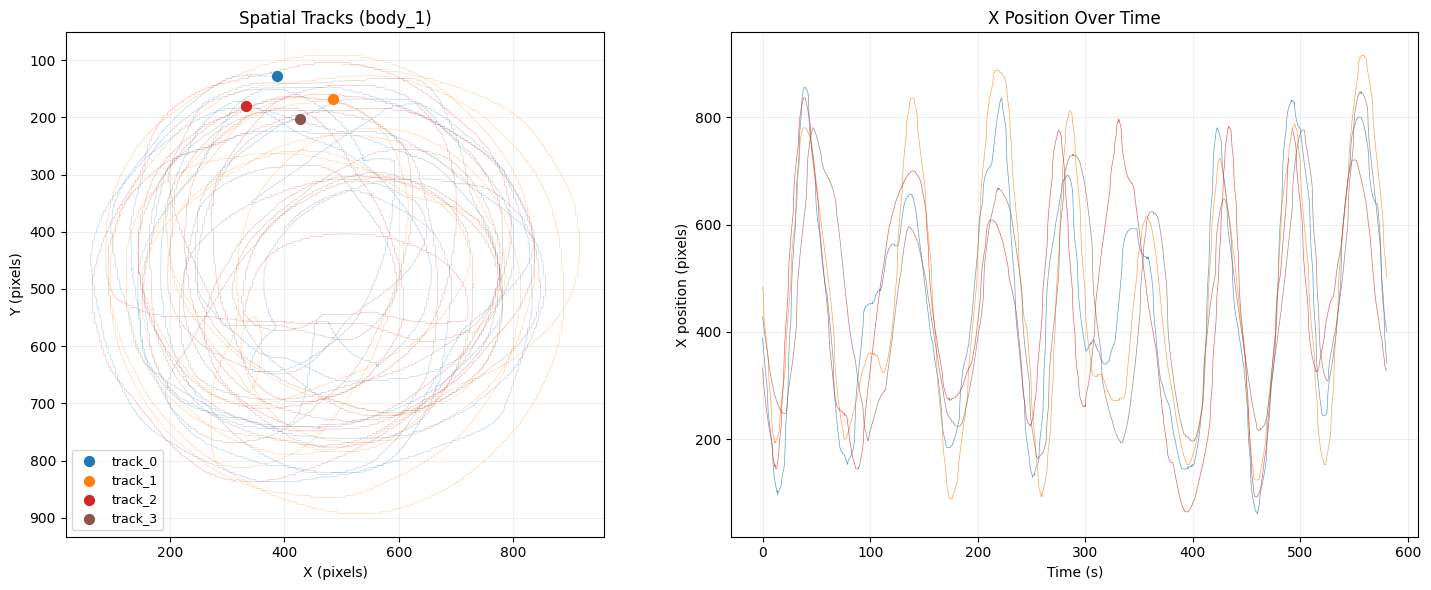

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for i in range(N_FISH):
    ax.plot(pos[:, i, 0], pos[:, i, 1], color=colors[i], alpha=0.35, linewidth=0.4)
    ax.scatter(pos[0, i, 0], pos[0, i, 1], color=colors[i], s=50, zorder=5, label=track_names[i])
ax.set_xlabel('X (pixels)'); ax.set_ylabel('Y (pixels)')
ax.set_title('Spatial Tracks (body_1)'); ax.legend(fontsize=9)
ax.set_aspect('equal'); ax.invert_yaxis(); ax.grid(True, alpha=0.2)

ax2 = axes[1]
for i in range(N_FISH):
    ax2.plot(t_sec, pos[:, i, 0], color=colors[i], alpha=0.7, linewidth=0.5)
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('X position (pixels)')
ax2.set_title('X Position Over Time'); ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{PNG_DIR}/fish_raw_tracks.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Derivative Reconstruction

In [4]:
def compute_derivatives(pos, dt, max_order):
    derivs = [pos.copy()]
    for _ in range(max_order):
        derivs.append(np.gradient(derivs[-1], dt, axis=0))
    return derivs

derivs = compute_derivatives(pos, DT, MAX_ORDER)

step_rms = np.nanstd(np.diff(pos[:,:,0], axis=0))
print(f'Step RMS (x-axis): {step_rms:.4f} px')
print()
print(f'{"Order":<8}{"Name":<16}{"RMS":<14}{"Taylor RMS":<16}{"% of step"}')
print('-'*60)
for k in range(MAX_ORDER + 1):
    rms = np.nanstd(derivs[k][:,:,0])
    if k == 0:
        print(f'{k:<8}{DERIV_NAMES[k]:<16}{rms:<14.4f}')
    else:
        t_rms = rms * (DT**k) / math.factorial(k)
        pct   = 100 * t_rms / step_rms
        print(f'{k:<8}{DERIV_NAMES[k]:<16}{rms:<14.4f}{t_rms:<16.6f}{pct:.3f}%')

Step RMS (x-axis): 1.2387 px

Order   Name            RMS           Taylor RMS      % of step
------------------------------------------------------------
0       Position        205.5980      
1       Velocity        25.2037       1.008148        81.391%
2       Acceleration    295.5985      0.236479        19.092%
3       Jerk            6649.1792     0.070925        5.726%
4       Snap            154337.9234   0.016463        1.329%


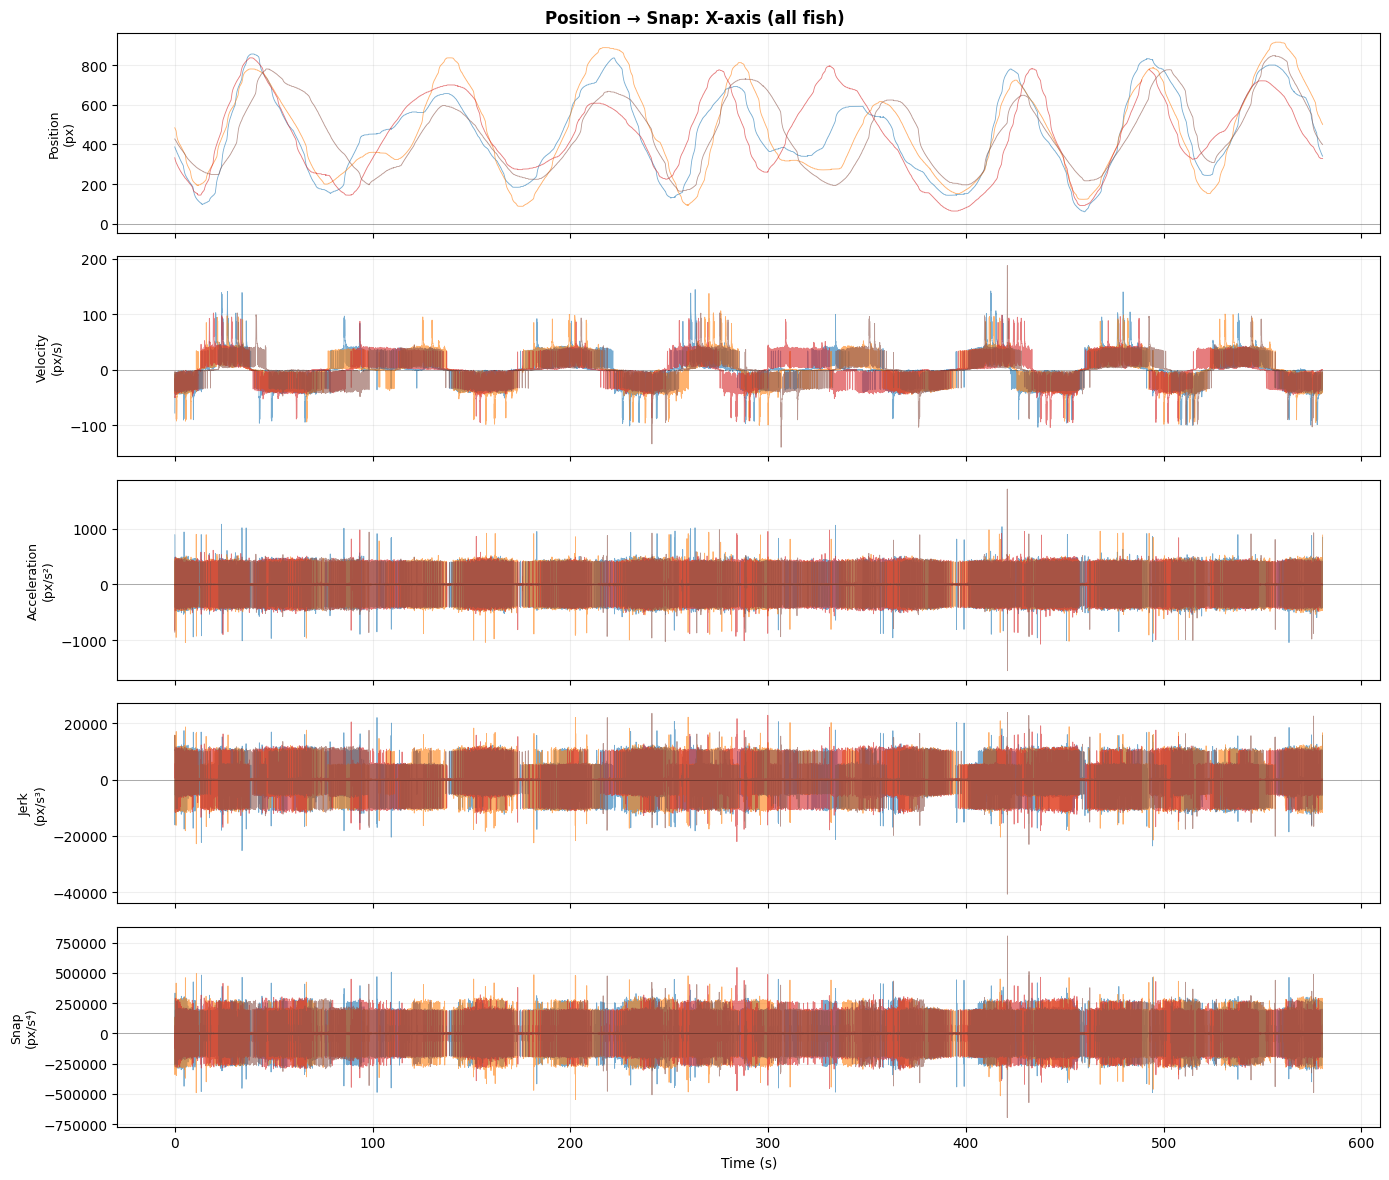

In [5]:
fig, axes = plt.subplots(MAX_ORDER+1, 1, figsize=(14, 12), sharex=True)
for k in range(MAX_ORDER+1):
    for i in range(N_FISH):
        axes[k].plot(t_sec, derivs[k][:,i,0], color=colors[i], alpha=0.6, linewidth=0.6)
    axes[k].set_ylabel(f'{DERIV_NAMES[k]}\n({DERIV_UNITS[k]})', fontsize=9)
    axes[k].grid(True, alpha=0.2)
    axes[k].axhline(0, color='k', linewidth=0.5, alpha=0.4)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Position → Snap: X-axis (all fish)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PNG_DIR}/fish_derivatives.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Autocorrelation & Whiteness Test
Once a derivative's autocorrelation is indistinguishable from white noise, higher orders carry no predictive signal.

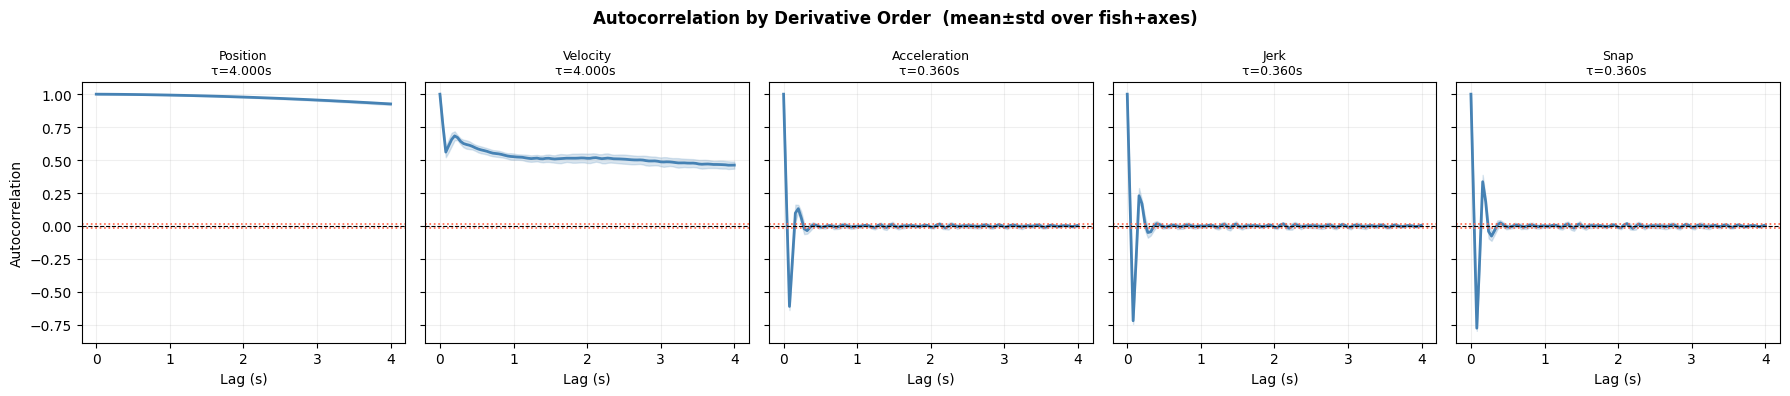

Position: τ=4.000s (100.0 frames)
Velocity: τ=4.000s (100.0 frames)
Acceleration: τ=0.360s (9.0 frames)
Jerk: τ=0.360s (9.0 frames)
Snap: τ=0.360s (9.0 frames)


In [6]:
MAX_LAG = 100
ci = 1.96 / np.sqrt(T)
lags_s = np.arange(MAX_LAG+1) * DT

def autocorr(x, max_lag):
    x = x - np.nanmean(x); x = np.nan_to_num(x)
    ac = np.correlate(x, x, mode='full')[len(x)-1:len(x)+max_lag]
    return ac / (ac[0] + 1e-10)

fig, axes = plt.subplots(1, MAX_ORDER+1, figsize=(18, 4), sharey=True)
tau_vals = []
for k in range(MAX_ORDER+1):
    acs = [autocorr(derivs[k][:,i,d], MAX_LAG)
           for i in range(N_FISH) for d in range(2)]
    ac_mean = np.mean(acs, axis=0)
    ac_std  = np.std(acs, axis=0)
    axes[k].fill_between(lags_s, ac_mean-ac_std, ac_mean+ac_std, alpha=0.2, color='steelblue')
    axes[k].plot(lags_s, ac_mean, color='steelblue', linewidth=2)
    axes[k].axhline(0,   color='k',      linewidth=0.8, linestyle='--')
    axes[k].axhline( ci, color='tomato', linewidth=1.2, linestyle=':')
    axes[k].axhline(-ci, color='tomato', linewidth=1.2, linestyle=':')
    below = np.where(np.abs(ac_mean) < ci)[0]
    tau   = lags_s[below[0]] if len(below) else lags_s[-1]
    tau_vals.append(tau)
    white = '⚪ WHITE' if tau < 2*DT else ''
    axes[k].set_title(f'{DERIV_NAMES[k]}\nτ={tau:.3f}s {white}', fontsize=9)
    axes[k].set_xlabel('Lag (s)'); axes[k].grid(True, alpha=0.2)
axes[0].set_ylabel('Autocorrelation')
fig.suptitle('Autocorrelation by Derivative Order  (mean±std over fish+axes)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PNG_DIR}/fish_autocorr.png', dpi=150, bbox_inches='tight')
plt.show()
for k,tau in enumerate(tau_vals):
    print(f'{DERIV_NAMES[k]}: τ={tau:.3f}s ({tau/DT:.1f} frames)')

## 4. Power Spectra

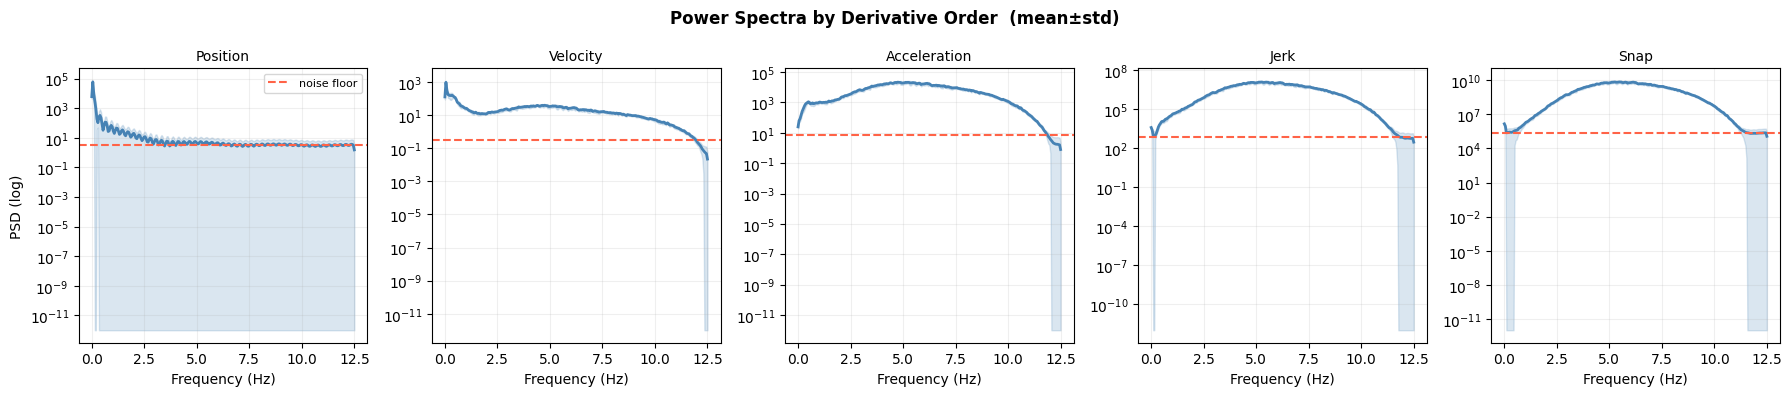

In [7]:
fig, axes = plt.subplots(1, MAX_ORDER+1, figsize=(18, 4))
for k in range(MAX_ORDER+1):
    psds = []
    for i in range(N_FISH):
        for d in range(2):
            f_freq, psd = signal.welch(np.nan_to_num(derivs[k][:,i,d]),
                                        fs=FPS, nperseg=min(512,T//8))
            psds.append(psd)
    pm = np.mean(psds, axis=0); ps_ = np.std(psds, axis=0)
    axes[k].semilogy(f_freq, pm, color='steelblue', linewidth=2)
    axes[k].fill_between(f_freq, np.maximum(pm-ps_,1e-12), pm+ps_, alpha=0.2, color='steelblue')
    axes[k].axhline(np.mean(pm[-20:]), color='tomato', linewidth=1.5,
                     linestyle='--', label='noise floor')
    axes[k].set_title(DERIV_NAMES[k], fontsize=10)
    axes[k].set_xlabel('Frequency (Hz)'); axes[k].grid(True, alpha=0.2, which='both')
    if k==0: axes[k].set_ylabel('PSD (log)'); axes[k].legend(fontsize=8)
fig.suptitle('Power Spectra by Derivative Order  (mean±std)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PNG_DIR}/fish_psd.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Taylor Truncation RMSE vs Order
Predict $p(t+\Delta t)$ using the Taylor expansion truncated at order $k$. RMSE plateau = effective order.

In [8]:
TRIM     = 10
idx      = np.arange(TRIM, T-TRIM-1)
pos_next = pos[TRIM+1:T-TRIM]
baseline = np.sqrt(np.nanmean((pos[idx] - pos_next)**2))

rmses, r2s = [], []
for k in range(1, MAX_ORDER+1):
    pred = pos[idx].copy()
    for o in range(1, k+1):
        pred = pred + derivs[o][idx] * (DT**o) / math.factorial(o)
    mask   = ~np.isnan(pos_next) & ~np.isnan(pred)
    rmse   = np.sqrt(np.nanmean((pred-pos_next)**2))
    r2     = r2_score(pos_next[mask], pred[mask])
    rmses.append(rmse); r2s.append(r2)
    imp = 100*(baseline-rmse)/baseline
    print(f'Order {k} ({DERIV_NAMES[k]:<14}): RMSE={rmse:.4f} px  R²={r2:.4f}  +{imp:.2f}% over baseline')
print(f'Baseline (no motion): RMSE={baseline:.4f} px')

Order 1 (Velocity      ): RMSE=0.7076 px  R²=1.0000  +42.12% over baseline
Order 2 (Acceleration  ): RMSE=0.5703 px  R²=1.0000  +53.35% over baseline
Order 3 (Jerk          ): RMSE=0.5745 px  R²=1.0000  +53.01% over baseline
Order 4 (Snap          ): RMSE=0.5812 px  R²=1.0000  +52.46% over baseline
Baseline (no motion): RMSE=1.2225 px


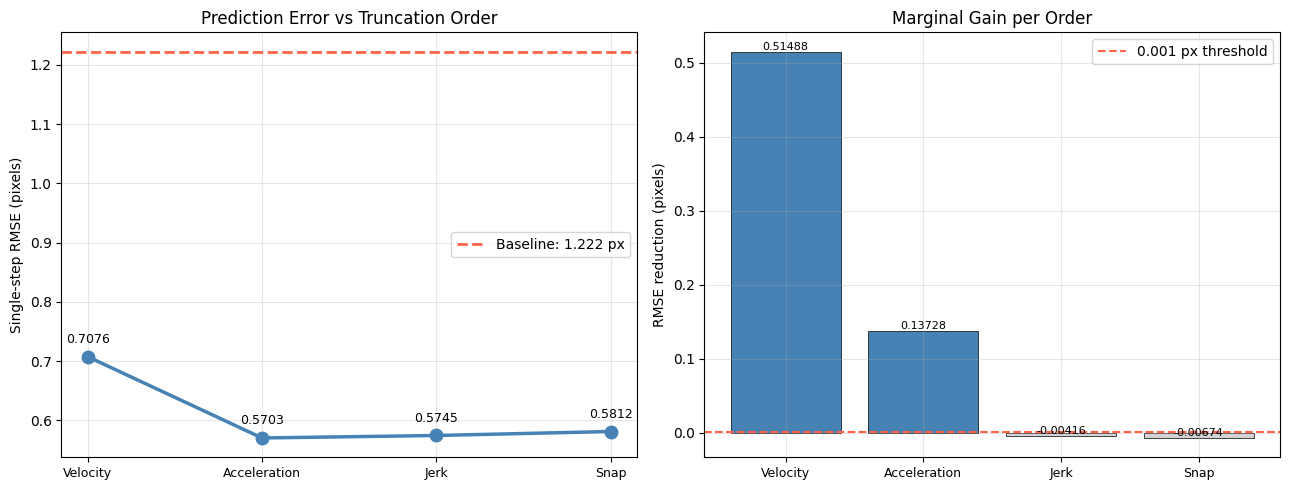

In [9]:
orders   = np.arange(1, MAX_ORDER+1)
marginal = -np.diff([baseline]+rmses)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(13,5))
ax1.plot(orders, rmses, 'o-', color='steelblue', linewidth=2.5, markersize=9)
ax1.axhline(baseline, color='tomato', linestyle='--', linewidth=2,
             label=f'Baseline: {baseline:.3f} px')
for o,r in zip(orders,rmses):
    ax1.annotate(f'{r:.4f}',(o,r), xytext=(0,10), textcoords='offset points',
                  ha='center', fontsize=9)
ax1.set_xticks(orders)
ax1.set_xticklabels([DERIV_NAMES[k] for k in orders], fontsize=9)
ax1.set_ylabel('Single-step RMSE (pixels)')
ax1.set_title('Prediction Error vs Truncation Order')
ax1.legend(); ax1.grid(True, alpha=0.3)

bar_c = ['steelblue' if m > 0.001 else 'lightgray' for m in marginal]
ax2.bar(orders, marginal, color=bar_c, edgecolor='k', linewidth=0.5)
ax2.axhline(0.001, color='tomato', linestyle='--', linewidth=1.5, label='0.001 px threshold')
for o,m in zip(orders,marginal):
    ax2.text(o, m+0.00005, f'{m:.5f}', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(orders)
ax2.set_xticklabels([DERIV_NAMES[k] for k in orders], fontsize=9)
ax2.set_ylabel('RMSE reduction (pixels)')
ax2.set_title('Marginal Gain per Order')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PNG_DIR}/fish_order_selection.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. LASSO Derivative Order Selection
$$\Delta p = \beta_1 v\Delta t + \beta_2 \tfrac{a}{2}\Delta t^2 + \beta_3 \tfrac{j}{6}\Delta t^3 + \beta_4 \tfrac{s}{24}\Delta t^4 + \epsilon$$
LASSO zeroes irrelevant $\beta_k$. Physics predicts all $\beta_k = 1$.

In [11]:
X_list, y_list = [], []
for i in range(N_FISH):
    for d in range(2):
        feats = np.column_stack([
            derivs[o][idx, i, d] * (DT**o) / math.factorial(o)
            for o in range(1, MAX_ORDER+1)
        ])
        target = pos_next[:, i, d] - pos[idx, i, d]
        # mask out any NaN in position, target, or any feature column
        mask = (np.isfinite(pos[idx, i, d]) &
                np.isfinite(target) &
                np.all(np.isfinite(feats), axis=1))
        X_list.append(feats[mask])
        y_list.append(target[mask])

X = np.vstack(X_list); y = np.concatenate(y_list)
feat_names = [DERIV_NAMES[k] for k in range(1, MAX_ORDER+1)]
print(f'LASSO samples: {len(y):,}  (dropped {(N_FISH*2*len(idx)) - len(y):,} NaN rows)')

lasso_cv = LassoCV(cv=5, max_iter=50000, n_alphas=200)
lasso_cv.fit(X, y)
print(f'Optimal α: {lasso_cv.alpha_:.6f}   R²: {lasso_cv.score(X,y):.4f}')
print()
for name, coef in zip(feat_names, lasso_cv.coef_):
    status = '✓ included' if abs(coef)>1e-6 else '✗ zeroed'
    print(f'  {name:<20}: β={coef:+.5f}  {status}')


LASSO samples: 115,588  (dropped 324 NaN rows)
Optimal α: 0.000993   R²: 0.8281

  Velocity            : β=+0.99903  ✓ included
  Acceleration        : β=+2.10923  ✓ included
  Jerk                : β=-0.00000  ✗ zeroed
  Snap                : β=+0.00000  ✗ zeroed


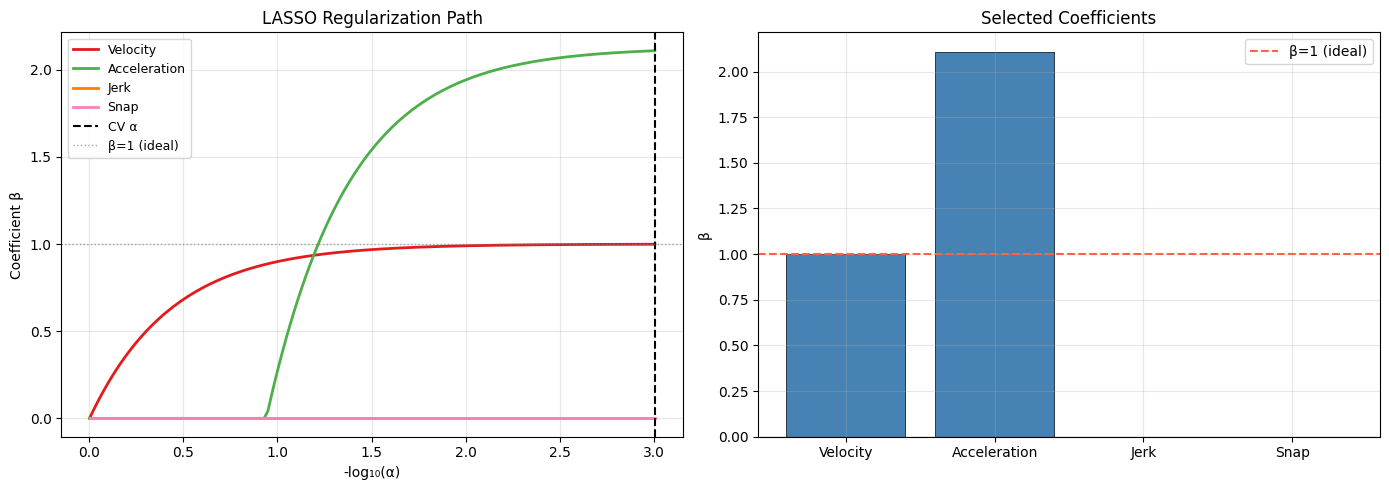

In [12]:
alphas, coefs, _ = lasso_path(X, y, n_alphas=150)
path_colors = plt.cm.Set1(np.linspace(0, 0.8, MAX_ORDER))

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
for i,name in enumerate(feat_names):
    ax1.plot(-np.log10(alphas), coefs[i], color=path_colors[i], linewidth=2, label=name)
ax1.axvline(-np.log10(lasso_cv.alpha_), color='k', linestyle='--', linewidth=1.5, label='CV α')
ax1.axhline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='β=1 (ideal)')
ax1.set_xlabel('-log₁₀(α)'); ax1.set_ylabel('Coefficient β')
ax1.set_title('LASSO Regularization Path'); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

bar_c = ['steelblue' if abs(c)>1e-6 else 'lightgray' for c in lasso_cv.coef_]
ax2.bar(feat_names, lasso_cv.coef_, color=bar_c, edgecolor='k', linewidth=0.5)
ax2.axhline(1.0, color='tomato', linestyle='--', linewidth=1.5, label='β=1 (ideal)')
ax2.axhline(0.0, color='k', linewidth=0.8)
ax2.set_ylabel('β'); ax2.set_title('Selected Coefficients'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PNG_DIR}/fish_lasso.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. SINDy: Sparse Identification of Nonlinear Dynamics
Fits $\dot{x} = \Theta(x)\xi$ where $\Theta$ is a polynomial library and $\xi$ is sparse.

In [14]:
def fill_nans(arr):
    t_all = np.arange(len(arr)); valid = ~np.isnan(arr)
    if valid.sum() < 2: return np.zeros_like(arr)
    return interp1d(t_all[valid], arr[valid], kind='linear',
                    bounds_error=False, fill_value='extrapolate')(t_all)

X_sindy = np.column_stack([fill_nans(pos[:,i,0]) for i in range(N_FISH)])

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=2, include_bias=True),
    optimizer=ps.STLSQ(threshold=0.05, alpha=0.05),
)
model.fit(X_sindy, t=DT, feature_names=[f'x{i}' for i in range(N_FISH)])
print('SINDy equations:')
model.print()
print(f'\nR²: {model.score(X_sindy, t=DT):.4f}')


SINDy equations:
(x0)' =  15.099 1 +  0.056 x0 + -0.090 x3
(x1)' =  0.000
(x2)' =  0.000
(x3)' =  0.000

R²: 0.0465


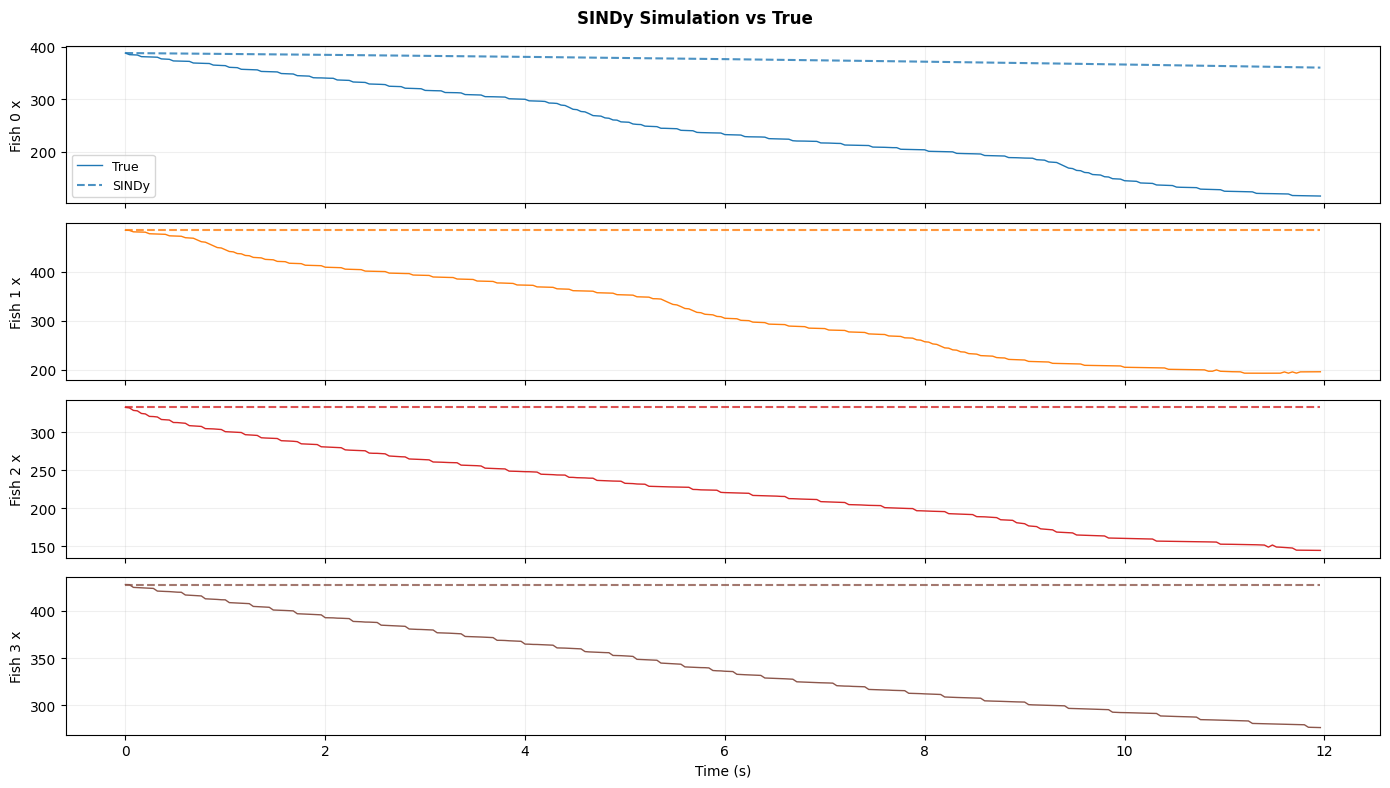

In [15]:
T_sim = min(300, T-1)
try:
    x_sim = model.simulate(X_sindy[0], t=np.arange(T_sim)*DT)
    fig, axes = plt.subplots(N_FISH, 1, figsize=(14,8), sharex=True)
    for i in range(N_FISH):
        axes[i].plot(np.arange(T_sim)*DT, X_sindy[:T_sim,i],
                     color=colors[i], linewidth=1, label='True')
        axes[i].plot(np.arange(T_sim)*DT, x_sim[:T_sim,i],
                     color=colors[i], linewidth=1.5, linestyle='--', alpha=0.8, label='SINDy')
        axes[i].set_ylabel(f'Fish {i} x'); axes[i].grid(True, alpha=0.2)
        if i==0: axes[i].legend(fontsize=9)
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle('SINDy Simulation vs True', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PNG_DIR}/fish_sindy.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'SINDy simulation unstable: {e}')

## 8. Social Structure of Jerk
If $j_i$ correlates with relative velocity $v_k - v_i$, jerk encodes real social interaction — worth modeling explicitly.

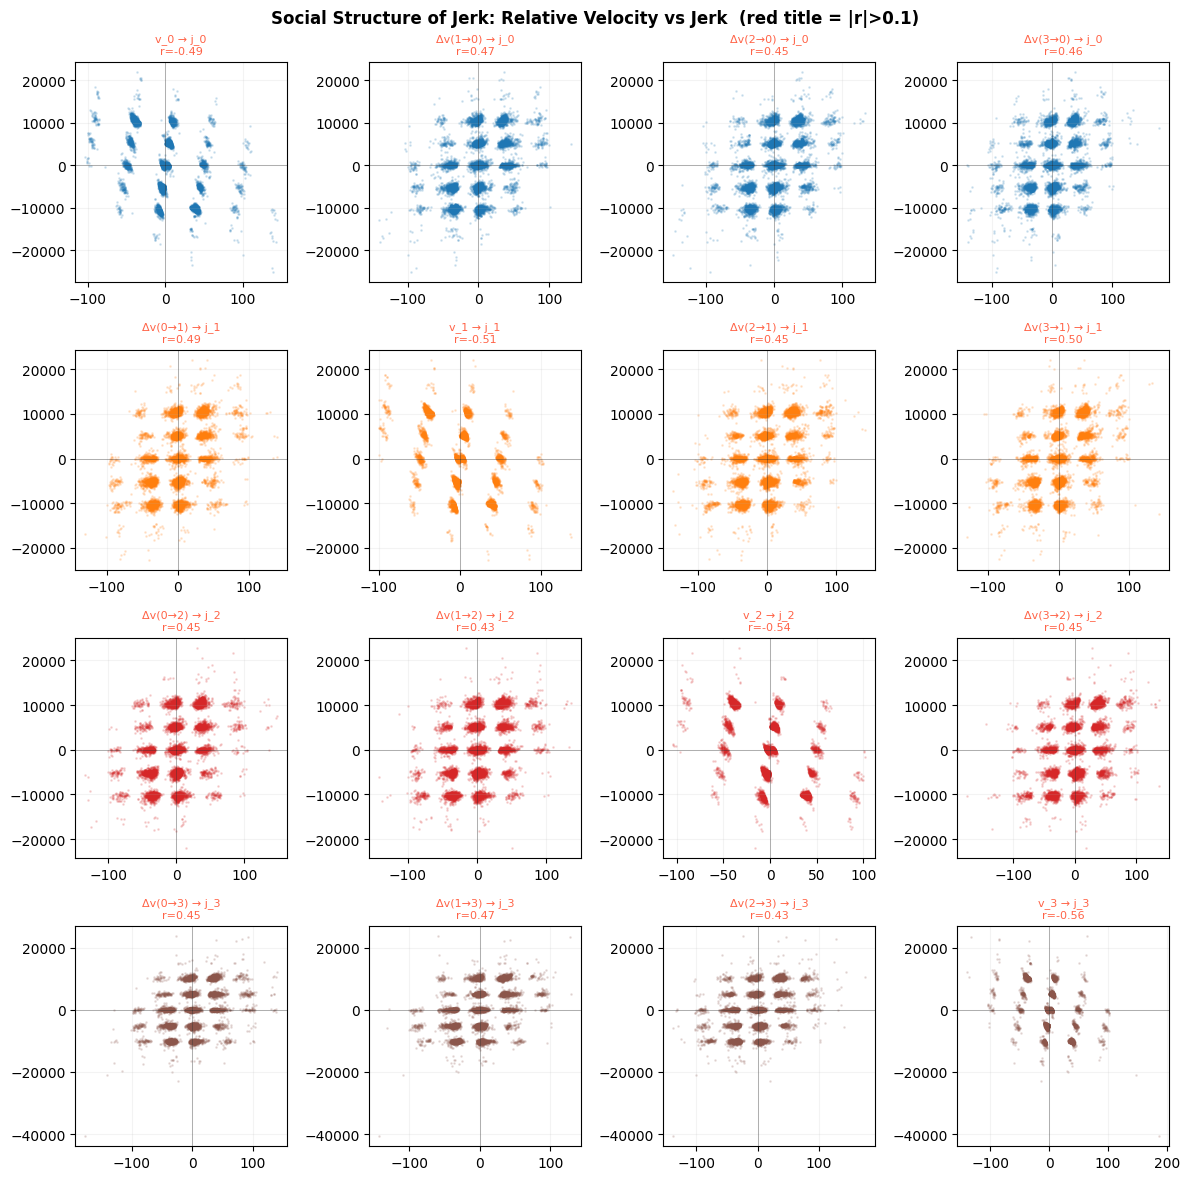

In [16]:
v = derivs[1][:,:,0]   # (T, fish)
a = derivs[2][:,:,0]
j = derivs[3][:,:,0]

fig, axes = plt.subplots(N_FISH, N_FISH, figsize=(12,12))
for i in range(N_FISH):
    for k in range(N_FISH):
        ax = axes[i,k]
        if i == k:
            sig = v[:,i]; label = f'v_{i} → j_{i}'
        else:
            sig = v[:,k] - v[:,i]; label = f'Δv({k}→{i}) → j_{i}'
        mask = ~np.isnan(j[:,i]) & ~np.isnan(sig)
        ax.scatter(sig[mask], j[mask,i], s=1, alpha=0.15, color=colors[i])
        r, p = pearsonr(sig[mask], j[mask,i])
        clr  = 'tomato' if abs(r) > 0.1 else 'black'
        ax.set_title(f'{label}\nr={r:.2f}', fontsize=8, color=clr)
        ax.axhline(0, color='k', linewidth=0.5, alpha=0.4)
        ax.axvline(0, color='k', linewidth=0.5, alpha=0.4)
        ax.grid(True, alpha=0.15)

fig.suptitle('Social Structure of Jerk: Relative Velocity vs Jerk  (red title = |r|>0.1)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{PNG_DIR}/fish_jerk_social.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

In [17]:
print('='*60)
print('DERIVATIVE ORDER ANALYSIS — SUMMARY')
print('='*60)
print(f'Dataset : 4 stickleback, {T} frames @ {FPS}fps, node={node_names[FOCUS_NODE]}')
print()
print('Taylor term contributions at dt=1/25s:')
for k in range(1, MAX_ORDER+1):
    rms = np.nanstd(derivs[k][:,:,0])
    t_rms = rms*(DT**k)/math.factorial(k)
    pct = 100*t_rms/step_rms
    print(f'  Order {k} ({DERIV_NAMES[k]:<14}): {pct:.3f}% of step size')
print()
print('Single-step RMSE:')
for k,(rmse,r2) in enumerate(zip(rmses,r2s),1):
    imp = 100*(baseline-rmse)/baseline
    print(f'  Order {k} ({DERIV_NAMES[k]:<14}): {rmse:.5f} px  R²={r2:.4f}  +{imp:.2f}%')
print(f'  Baseline                : {baseline:.5f} px')
print()
print('Autocorrelation timescales:')
for k,tau in enumerate(tau_vals):
    print(f'  {DERIV_NAMES[k]:<16}: τ={tau:.3f}s ({tau/DT:.1f} frames)')
print()
selected = [feat_names[i] for i,c in enumerate(lasso_cv.coef_) if abs(c)>1e-6]
print(f'LASSO selected: {selected}')
print()
print('Recommendation:')
print('  If velocity   term dominates → order 1 may suffice')
print('  If accel      gives big RMSE drop → use order 2')
print('  If jerk AC is structured + LASSO keeps it → use order 3')
print('  If social jerk correlation |r|>0.1 → jerk encodes interaction, model it')

DERIVATIVE ORDER ANALYSIS — SUMMARY
Dataset : 4 stickleback, 14510 frames @ 25fps, node=body_1

Taylor term contributions at dt=1/25s:
  Order 1 (Velocity      ): 81.391% of step size
  Order 2 (Acceleration  ): 19.092% of step size
  Order 3 (Jerk          ): 5.726% of step size
  Order 4 (Snap          ): 1.329% of step size

Single-step RMSE:
  Order 1 (Velocity      ): 0.70759 px  R²=1.0000  +42.12%
  Order 2 (Acceleration  ): 0.57031 px  R²=1.0000  +53.35%
  Order 3 (Jerk          ): 0.57447 px  R²=1.0000  +53.01%
  Order 4 (Snap          ): 0.58121 px  R²=1.0000  +52.46%
  Baseline                : 1.22248 px

Autocorrelation timescales:
  Position        : τ=4.000s (100.0 frames)
  Velocity        : τ=4.000s (100.0 frames)
  Acceleration    : τ=0.360s (9.0 frames)
  Jerk            : τ=0.360s (9.0 frames)
  Snap            : τ=0.360s (9.0 frames)

LASSO selected: ['Velocity', 'Acceleration']

Recommendation:
  If velocity   term dominates → order 1 may suffice
  If accel      gi